# StarGunner

StarGunner is een klassiek Atari-spel uit 1982, gemaakt door Imagitec Design (Wikipedia, z.d.). Je bestuurt een ruimteschip dat vijanden moet vernietigen en aanvallen moet ontwijken.

Dit spel is geschikt voor Reinforcement Learning (RL), omdat een AI-agent hier zelf een strategie kan leren door te spelen en ervaring op te doen, zonder vooraf gegeven regels.

### Gameplay
De speler bestuurt een ruimteschip dat:
-	vijanden moet uitschakelen voor punten
-	schoten moet ontwijken
-	levels moet voltooien
Je kunt bewegen en schieten.
Als je geraakt wordt, verlies je een leven.

### Waarom StarGunner
Wij hebben gekozen voor StarGunner, omdat het een goede testomgeving is voor Reinforcement Learning. Een agent kan hier leren door ervaring op te doen en beloningen te krijgen. StarGunner maakt deel van Arcade Learning Environment (ALE) in Gymnasium (Farama Foundation, z.d.), wat zorgt voor een eenvoudige implementatie.

StarGunner is handig voor RL omdat:
-	Duidelijke beloningen (punten en verliezen)
-	Simpele acties (bewegen en schieten)
-	Visuele input (beelden van het spel)
-	Dynamische omgeving (het spel verandert steeds)
-   Het spel is episodisch: Elke level of leven is een duidelijke afgebakende episode. Dit maakt het leerproces overzichtelijk  voor RL.
-   Vertraging in beloning (een schot die vijand raakt levert later pas de punten op, waardoor de agent langetermijnstrategie moet leren)


https://gymnasium.farama.org/v0.27.1/environments/atari/star_gunner/

https://trolleyman.org/assets/Dissertation-CPu2ZB6p.pdf

https://en.wikipedia.org/wiki/Stargunner


### Inhoudsopgave
1. Libraries
2. Wat is Reinforcement Learning?
3. ALE/StarGunner-v5
4. Replay Memory
5. Het DQN-netwerk
6. Random Baseline
7. Conclusie
8. Bronnen

## 2. Wat is Reinforcement Learning?

**Reinforcement Learning (RL)** is een manier van leren waarbij een *agent* leert door te doen. In Reinforcement Learning leert een agent door te proberen en te kijken wat er gebeurt.
Het doel van de agent wordt bepaald door de reinforcement function (beloningsfunctie).

De kern van Reinforcement Learning is de interactie tussen een agent en zijn omgeving.
Deze interactie kun je zien als een doorlopende cyclus:

```
Agent ──(actie)──▶ Omgeving ──(nieuwe staat + beloning)──▶ Agent
```
- **State**: De huidige situatie 
- **Actie**: Wat de agent doet

Hoe leert de agent?

De agent:

1. zit in een bepaalde situatie (state)
2. kiest een actie
3. krijgt een beloning
4. leert welke acties op de lange termijn het beste zijn

Hij probeert dus acties te vinden die uiteindelijk de meeste beloning opleveren.

De agent krijgt **geen** labels of instructies. Hij ontdekt zelf wat werkt via trial & error.

### 2.1. Verschil met Supervised Learning

Reinforcement Learning (RL) is op een aantal belangrijke punten anders dan Supervised Learning:
- Geen vaste input en output

De agent krijgt niet te horen wat de beste keuze was op de lange termijn.

- Zelf ervaring opdoen

De agent moet zelf ontdekken wat werkt en wat niet.
Hij leert door acties uit te proberen en te kijken wat het resultaat is. Zo bouwt hij ervaring op.

- Leren en presteren tegelijk

Bij RL gebeurt leren vaak terwijl het systeem al gebruikt wordt.
Dat betekent dat het belangrijk is dat de agent tijdens het leren al zo goed mogelijk presteert.

### 2.2. Modellen van optimaal gedrag

Voordat je een goed algoritme kunt maken, moet je bepalen wat “optimaal gedrag” betekent.
Dit heeft te maken met hoe belangrijk toekomstige beloningen zijn.

Er zijn drie belangrijke modellen:

1. Eindige-horizon model

De agent kijkt alleen naar een vast aantal stappen in de toekomst.

2. Oneindige-horizon met korting (discounted model)

De agent kijkt naar de lange termijn, maar toekomstige beloningen tellen minder zwaar mee.

3. Gemiddelde-beloning model

De agent probeert de gemiddelde beloning over een lange tijd zo hoog mogelijk te maken.


### 2.3. Exploratie/exploitatie

Een belangrijk verschil met Supervised Learning is dat een RL-agent zelf nieuwe dingen moet uitproberen om te ontdekken wat goed werkt (exploratie).

- Exploitatie: je kiest voor iets waarvan je al weet dat het goed werkt. Je gebruikt dus je huidige kennis om de beste keuze te maken en zoveel mogelijk beloning te krijgen.

- Exploratie: je probeert iets nieuws dat je nog niet goed kent. Het kan beter zijn, maar dat weet je nog niet zeker. Je doet dit om meer te leren en mogelijk betere keuzes te vinden.




https://apps.dtic.mil/sti/tr/pdf/ADA323194.pdf

https://arxiv.org/pdf/cs/9605103

## 3. ALE/StarGunner-v5

Voor dit project gebruiken we de omgeving ALE/StarGunner-v5 uit de Gymnasium
bibliotheek. ALE staat voor Arcade Learning Environment, een platform dat
klassieke Atari-spellen beschikbaar maakt als trainingsomgeving voor RL-agents.

### 3.1. Omgeving
De omgeving geeft de agent bij elke stap een observatie, een beloning en een
signaal of het spel voorbij is. Wij gebruiken de RAM-versie van de omgeving
(StarGunner-ram-v5). In plaats van een schermafbeelding krijgt de agent 128
bytes aan RAM-geheugen als invoer. Dit geheugen bevat informatie zoals de
positie van het ruimteschip, vijanden en schoten.

### 3.2. Observatie en actieruimte
-   Observatieruimte: 128 bytes (integers van 0–255)
-   Actieruimte: 18 mogelijke acties (bewegen in 8 richtingen + schieten)
-   Beloning: punten voor het neerschieten van vijanden
-   Episode: afgelopen als alle levens op zijn

### 3.3. Preprocessing
De RAM-waarden worden genormaliseerd naar het bereik [0, 1] door elke waarde
te delen door 255. Dit helpt het neurale netwerk stabieler te trainen, omdat
alle invoerwaarden dezelfde schaal hebben.

## 4. Replay Memory

## 5. Het DQN-netwerk

Het Deep Q-Network (DQN) is een methode die Deep Learning en Reinforcement Learning (Q-learning) combineert.

Het wordt gebruikt om moeilijke problemen op te lossen, zoals het spelen van computerspellen, 
waarbij de agent leert direct van beelden (visuele input), of in ons geval de RAM-toestand 
van de emulator, in plaats van vooraf gegeven regels of data.

**Kernidee**
In Q-learning wordt een Q-tabel bijgehouden met de verwachte beloning voor elke 
combinatie van situatie en actie. Bij meer complexe omgevingen zoals StarGunner is dit echter onmogelijk, 
omdat de toestandsruimte (alle mogelijke schermbeelden) te groot is.

In plaats van een grote Q-tabel gebruikt DQN een neuraal netwerk dat de Q-waarden schat:

Q(s, a) ≈ Q(s, a; θ)

Hier is s de huidige situatie (state), a de gekozen actie, 0 de gewichten van het netwerk.
Dit netwerk kijkt naar de huidige situatie (state) en voorspelt de Q-waarden voor alle mogelijke acties.
De agent kiest de actie met de hoogste Q-waarde.

Die Q-waarden geven aan hoe goed een actie op lange termijn is.

### 5.1. Invoer
Dit model gebruikt de RAM versie van de Atari-emulator. In plaats van pixelbeelden gebruiken wij RAM geheugen van 128 bytes met informatie zoals de positie van het ruimteschip, de vijanden en schoten.

Dit heeft een aantal voordelen:
-	Invoer is kleiner (128 bytes vs duizenden pixels)
-	Hierdoor is de convolutioneel neuraal netwerk (CNN) niet nodig
-	Het netwerk traint sneller

### 5.2. Policy
Om de balans tussen exploratie en exploitatie te behouden, gebruikt DQN epsilon-greedy strategie. (GeeksforGeeks, 2025).
-	Met kans e kiest de agent een willekeurige actie (exploratie).
-	Met kans 1-e kiest de agent de actie met de hoogste Q-waarde (exploitatie)


Het e is hoog in het begin van het trainen, omdat de agent eerst de omgeving moet herkennen.
Gedurende trainen wordt e steeds kleiner, omdat de agent meer op zijn kennis vertrouwt.


### 5.3. Belangrijke technieken

1. Experience replay

De agent slaat ervaringen op (situatie, actie, beloning, volgende situatie).

Tijdens het leren worden willekeurige ervaringen uit geheugen gebruikt.

Dit zorgt ervoor dat:
- het leren efficiënter wordt
- de data minder “door elkaar verbonden” is
- het leerproces stabieler wordt


2. Target network

DQN gebruikt twee netwerken:
- een online netwerk dat leert
- een target netwerk dat stabiele doelen geeft

Het target netwerk wordt af en toe bijgewerkt.

DQN laat een agent leren van ruwe input en acties kiezen zonder Q-tabel.
Door experience replay en target network wordt het leerproces stabiel en beter.

https://huggingface.co/learn/deep-rl-course/unit3/deep-q-algorithm

https://trolleyman.org/assets/Dissertation-CPu2ZB6p.pdf

https://www.geeksforgeeks.org/deep-learning/deep-q-learning/

https://www.geeksforgeeks.org/machine-learning/epsilon-greedy-algorithm-in-reinforcement-learning/

## 6. Random Baseline

Om te controleren of onze DQN-agent echt leert, vergelijken we hem met een random agent.
Deze agent kiest bij elke stap willekeurig een actie, zonder plan of geheugen.

Als de DQN-agent niet beter presteert dan de random agent, betekent dit dat ons algoritme niet goed werkt.

### Resultaten random baseline
De random baseline behaalt een gemiddelde reward van ongeveer 650–700 over
2000 episodes. Deze score is relatief hoog voor een willekeurige agent, wat
komt doordat StarGunner automatisch schoten afvuurt, dus ook zonder strategie worden er af en toe vijanden geraakt.

## 7. Experimenten

Om het DQN-model te optimaliseren hebben wij de volgende varianten getest met twee hyperparameters:
-   netwerkarchitectuur
-   minimale exploratiewaarde (epsilon_min)

| Model | Architectuur | epsilon_min |
|---|---|---|
| 1 | (256,) | 0.01 |
| 2 | (256,) | 0.05 |
| 3 | (256, 128) | 0.01 |
| 4 | (256, 128) | 0.05 |
| 5 | (256, 128, 64) | 0.01 |
| 6 | (256, 128, 64) | 0.05 |

Alle modellen zijn getraind over 2000 episodes en vergeleken met een random baseline. De resultaten zijn weergegeven in de twee grafieken hieronder.

Vergelijking van epsilon_min = 0.01

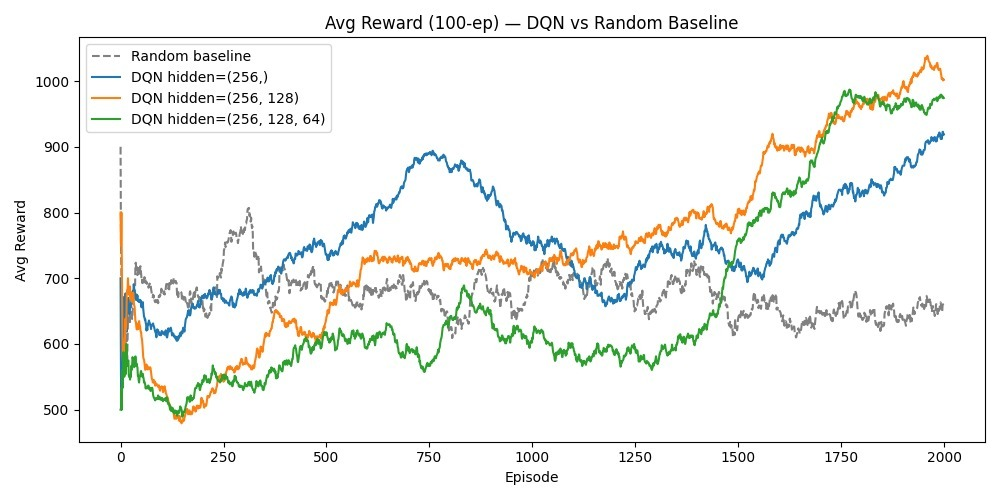

Bij epsilon_min=0.01 presteert het 2-laags netwerk (256, 128) het best. Het bereikt een gemiddelde reward van 1000-1100 na 2000 episodes en toont stabiele groei na ongeveer 1750 episodes. Het 3-laags netwerk haalt een vergelijkbare eindscore, maar met meer instabiliteit onderweg. Het 1-laags netwerk presteert het zwakst van de drie.

Vergelijking van epsilon_min = 0.05


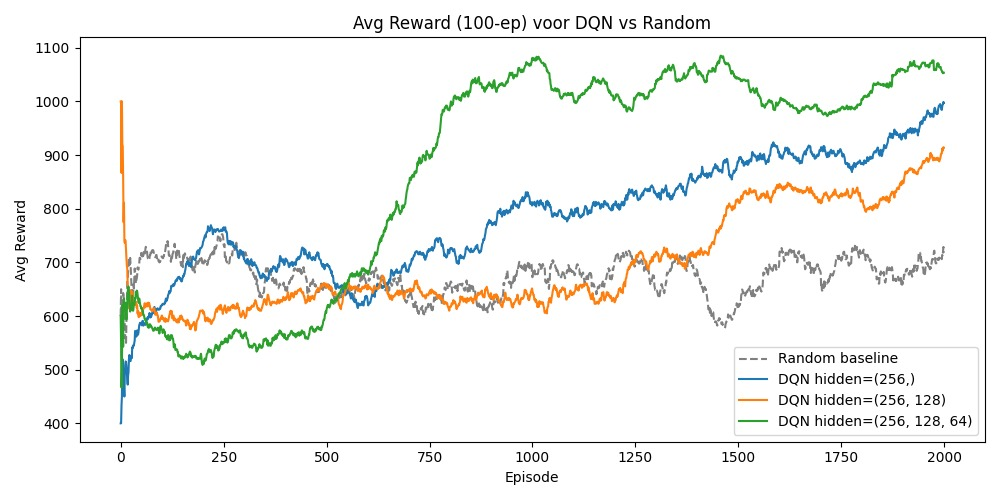

Bij epsilon_min=0.05 is het 3-laags netwerk (256, 128, 64) duidelijk de winnaar. Het stijgt al vanaf 750 episodes sterk en bereikt een gemiddelde reward van 1050–1100, consistent hoger dan de andere varianten. Opvallend is dat het 2-laags netwerk hier juist achterblijft ten opzichte van zijn prestatie bij epsilon_min=0.01.

Alle zes DQN-varianten presteren uiteindelijk beter dan de random baseline (ongeveer 700),
wat laat zien dat de agent echt iets leert.

### 7.1. Modelcapaciteit en exploratie
Uit de resultaten blijkt dat grotere netwerken meer exploratie nodig hebben.
Een 3-laags netwerk heeft veel meer parameters dan een kleiner netwerk.
Om goed te leren, heeft het veel verschillende situaties nodig in de replay buffer.
Met epsilon_min=0.05 blijft de agent tot het einde 5% willekeurige acties doen,
waardoor de buffer gevarieerder blijft. Bij epsilon_min=0.01 stopt de exploratie
te vroeg en leert het netwerk van te weinig verschillende situaties.

Een 2-laags netwerk leert sneller en stabieler. Als epsilon laag is, zijn de
leersignalen consistenter: minder ruis en meer verfijning. Een kleiner netwerk
heeft minder variatie in zijn ervaringen nodig om goed te werken.

Dit is vergelijkbaar met de bias-variance tradeoff: grotere netwerken maken
meer fouten in hun schattingen en hebben daarom meer gevarieerde ervaringen
nodig. Kleinere netwerken maken stabielere schattingen en leren ook met minder data.

| | epsilon_min = 0.05 | epsilon_min = 0.01 |
|---|---|---|
| **3 lagen** | Diverse data vult de capaciteit | Te weinig variatie, ondertrained |
| **2 lagen** | Extra ruis, overkill | Stabiele verfijning, snel genoeg |

Op basis van deze experimenten is het 3-laags netwerk met epsilon_min=0.05 de beste configuratie: het behaalt de hoogste gemiddelde reward en toont de meest consistente verbetering over de 2000 episodes. Wanneer trainingstijd of rekenkracht een beperking is, biedt het 2-laags netwerk met epsilon_min=0.01 een goed alternatief met stabiele prestaties.

### 7.2. Individuele modellen

**1 hidden layer, epsilon_min=0.05**
Dit model leert consistent. De reward stijgt vrijwel de hele training
door, van ~400 naar ~1000 na 2000 episodes. Er is een tijdelijke dip rond episode
500–750, maar daarna herstelt het model zich en blijft het groeien. De epsilon
decay laat zien dat de exploratie snel daalt en stabiel blijft op 0.05.

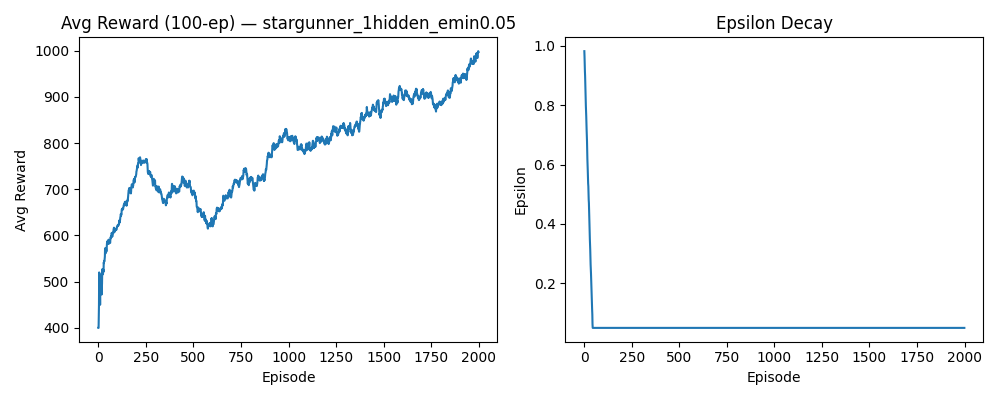

**2 hidden layers, epsilon_min=0.05**
Dit model start instabiel. Er is een vroege piek van ~1000 gevolgd door een
scherpe daling naar ~600. Pas vanaf episode 1250 begint het model echt te leren
en stijgt de reward naar ~900. De trage start suggereert dat het netwerk meer
tijd nodig heeft om de extra laag goed te benutten.

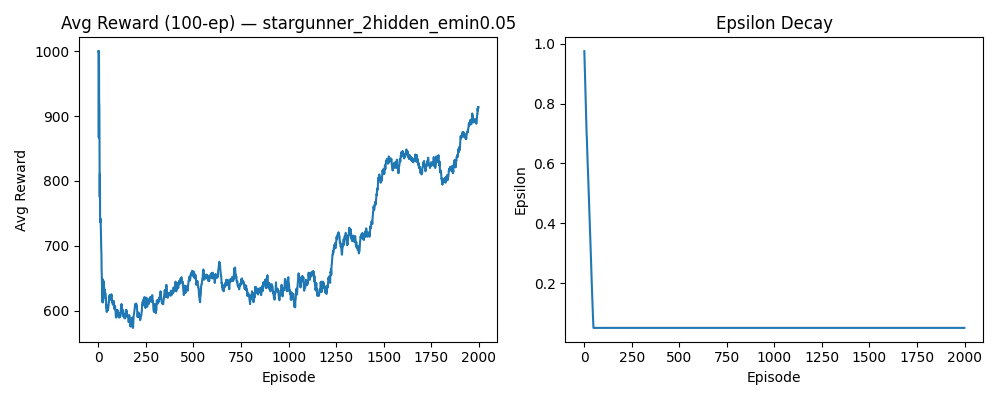

**3 hidden layers, epsilon_min=0.05**
Dit is het beste model. Vanaf episode 750 stijgt de reward snel naar ~1050 en
blijft daarna stabiel hoog. De hogere exploratie zorgt ervoor dat het diepe
netwerk genoeg verschillende situaties ziet en zijn kennis benut.

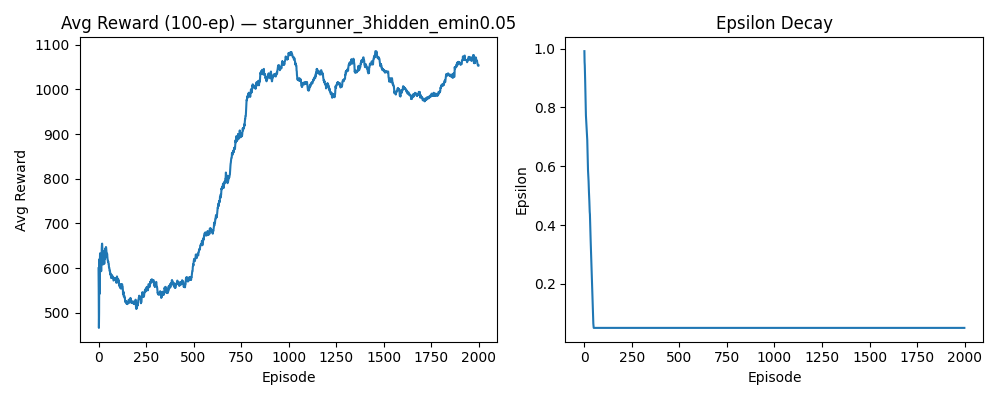

## 8. Conclusie

## 9. Bronnen

-   Farama Foundation. (z.d.). StarGunner - Gymnasium documentation (v0.27.1). https://gymnasium.farama.org/v0.27.1/environments/atari/star_gunner/
-   GeeksforGeeks. (2023, January 10). Epsilon-greedy algorithm in reinforcement learning. https://www.geeksforgeeks.org/machine-learning/epsilon-greedy-algorithm-in-reinforcement-learning/
-   GeeksforGeeks. (2025, October 9). Deep Q-learning in reinforcement learning. https://www.geeksforgeeks.org/deep-learning/deep-q-learning/
-   Hugging Face. (z.d.). The deep Q-learning algorithm. Deep RL Course. https://huggingface.co/learn/deep-rl-course/unit3/deep-q-algorithm
-   Kaelbling, L. P., Littman, M. L., & Moore, A. W. (1996). Reinforcement learning: A survey. Journal of Artificial Intelligence Research, 4, 237–285. https://arxiv.org/pdf/cs/9605103
-   Tolley, C. G. (z.d.). Artificial intelligence in Atari 2600 games using deep Q-learning [Masterthesis, University of Birmingham]. https://trolleyman.org/assets/Dissertation-CPu2ZB6p.pdf
-   Wikipedia. (z.d.). Stargunner. https://en.wikipedia.org/wiki/Stargunner
